## Import the Libraries

In [1]:
# ! pip install pandas numpy matplotlib seaborn scikit-learn
# ! pip install lightgbm catboost xgboost shap skl2onnx onnxmltools onnxruntime joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('../training/data/heart.csv')
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.00,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.00,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.00,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.50,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.00,Up,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## Data Cleaning

The Kaggle heart dataset encodes some missing clinical values as `0`, which is
physiologically impossible: `Cholesterol` has 172 such zeros and `RestingBP`
has 1. Left in place they pull the distributions toward zero and mislead both
the scaler and the models. We treat these zeros as missing, impute the column
median, and drop any exact duplicate rows.

In [5]:
# Zeros that really mean "missing" -> NaN -> median impute.
for c in ['Cholesterol', 'RestingBP']:
    n_zero = int((data[c] == 0).sum())
    data[c] = data[c].replace(0, np.nan)
    median = data[c].median()
    data[c] = data[c].fillna(median)
    print(f'{c}: replaced {n_zero} zero(s) with median {median:.1f}')

n_dupes = int(data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
print(f'Dropped {n_dupes} duplicate row(s); {len(data)} rows remain')

Cholesterol: replaced 172 zero(s) with median 237.0
RestingBP: replaced 1 zero(s) with median 130.0
Dropped 0 duplicate row(s); 918 rows remain


In [6]:
col = list(data.columns)
categorical_features = []
numerical_features = []
for i in col:
    if len(data[i].unique()) > 6:
        numerical_features.append(i)
    else:
        categorical_features.append(i)

print('Categorical Features :',*categorical_features)
print('Numerical Features :',*numerical_features)

Categorical Features : Sex ChestPainType FastingBS RestingECG ExerciseAngina ST_Slope HeartDisease
Numerical Features : Age RestingBP Cholesterol MaxHR Oldpeak


In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = data.copy(deep = True)

df1['Sex'] = le.fit_transform(df1['Sex'])
df1['ChestPainType'] = le.fit_transform(df1['ChestPainType'])
df1['RestingECG'] = le.fit_transform(df1['RestingECG'])
df1['ExerciseAngina'] = le.fit_transform(df1['ExerciseAngina'])
df1['ST_Slope'] = le.fit_transform(df1['ST_Slope'])

In [8]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

df1['Oldpeak'] = mms.fit_transform(df1[['Oldpeak']])
df1['Age'] = ss.fit_transform(df1[['Age']])
df1['RestingBP'] = ss.fit_transform(df1[['RestingBP']])
df1['Cholesterol'] = ss.fit_transform(df1[['Cholesterol']])
df1['MaxHR'] = ss.fit_transform(df1[['MaxHR']])
df1.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,-1.43,1,1,0.42,0.86,0,1,1.38,0,0.30,2,0
1,-0.48,0,2,1.53,-1.18,0,1,0.75,0,0.41,1,1
2,-1.75,1,1,-0.14,0.75,0,2,-1.53,0,0.30,2,0
3,-0.58,0,0,0.30,-0.55,0,1,-1.13,1,0.47,1,1
4,0.05,1,2,0.97,-0.90,0,1,-0.58,0,0.30,2,0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import precision_recall_curve

In [10]:
drop_cols = ['HeartDisease', 'RestingBP', 'RestingECG']
feature_names = list(df1.columns.drop(drop_cols))
features = df1[feature_names].values
target = df1['HeartDisease'].values
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state = 2)
print('Features used:', feature_names)

Features used: ['Age', 'Sex', 'ChestPainType', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [11]:
colors = ['#F93822','#FDD20E']

def model(classifier):
    
    classifier.fit(x_train,y_train)
    prediction = classifier.predict(x_test)
    cv = RepeatedStratifiedKFold(n_splits = 10,n_repeats = 3,random_state = 1)
    print("Accuracy : ",'{0:.2%}'.format(accuracy_score(y_test,prediction)))
    print("Cross Validation Score : ",'{0:.2%}'.format(cross_val_score(classifier,x_train,y_train,cv = cv,scoring = 'roc_auc').mean()))
    print("ROC_AUC Score : ",'{0:.2%}'.format(roc_auc_score(y_test,prediction)))
    RocCurveDisplay.from_estimator(classifier, x_test,y_test)
    plt.title('ROC_AUC_Plot')
    plt.show()

def model_evaluation(classifier):
    
    # Confusion Matrix
    cm = confusion_matrix(y_test,classifier.predict(x_test))
    names = ['True Neg','False Pos','False Neg','True Pos']
    counts = [value for value in cm.flatten()]
    percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(names,counts,percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cm,annot = labels,cmap = colors,fmt ='')
    
    # Classification Report
    print(classification_report(y_test,classifier.predict(x_test)))

### 1. Logistic Regression

Accuracy :  85.33%


Cross Validation Score :  91.19%
ROC_AUC Score :  85.29%


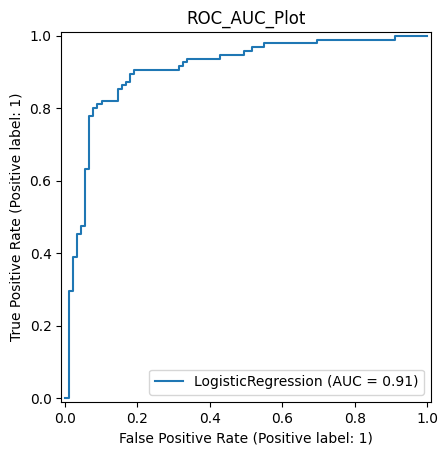

In [12]:
from sklearn.linear_model import LogisticRegression

classifier_lr = LogisticRegression(random_state = 0,C=10,penalty= 'l2') 

model(classifier_lr)

Accuracy :  82.07%


Cross Validation Score :  90.35%
ROC_AUC Score :  82.06%


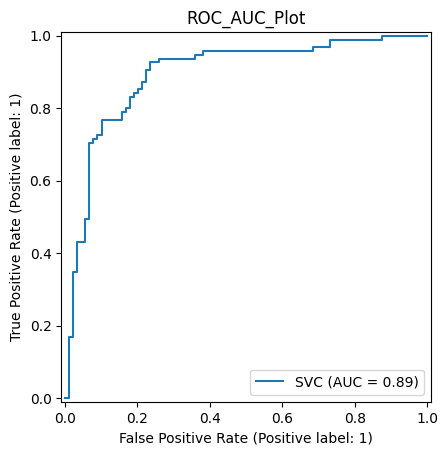

In [13]:
from sklearn.svm import SVC

classifier_svc = SVC(kernel = 'linear',C = 0.1)
model(classifier_svc)

              precision    recall  f1-score   support

           0       0.81      0.82      0.82        89
           1       0.83      0.82      0.83        95

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



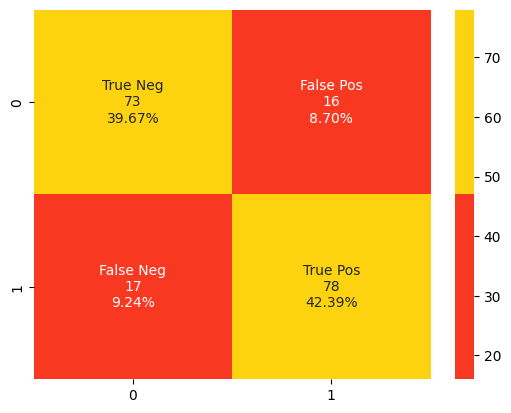

In [14]:
model_evaluation(classifier_svc)

Accuracy :  84.24%
Cross Validation Score :  88.09%
ROC_AUC Score :  84.28%


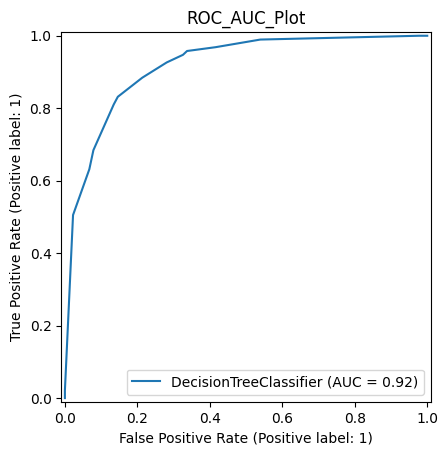

In [15]:
from sklearn.tree import DecisionTreeClassifier

classifier_dt = DecisionTreeClassifier(random_state = 1000,max_depth = 4,min_samples_leaf = 1)
model(classifier_dt)

Accuracy :  83.70%


Cross Validation Score :  92.47%
ROC_AUC Score :  83.47%


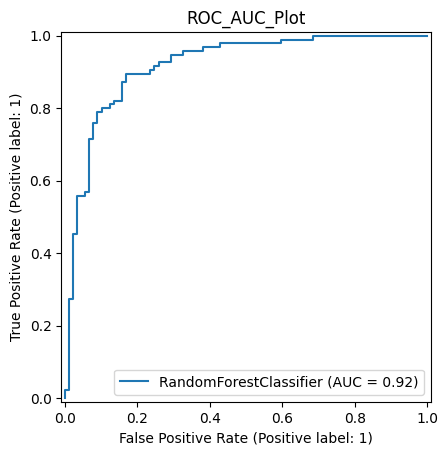

In [16]:
from sklearn.ensemble import RandomForestClassifier

classifier_rf = RandomForestClassifier(max_depth = 4,random_state = 0)
model(classifier_rf)

### 5. LightGBM

Accuracy :  85.33%


Cross Validation Score :  92.46%
ROC_AUC Score :  85.19%


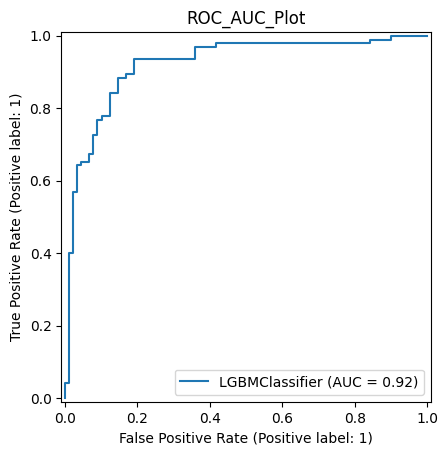

In [17]:
from lightgbm import LGBMClassifier

classifier_lgbm = LGBMClassifier(n_estimators = 200, max_depth = 3, learning_rate = 0.05,
                                 random_state = 42, n_jobs = 1, verbose = -1)
model(classifier_lgbm)

              precision    recall  f1-score   support

           0       0.88      0.81      0.84        89
           1       0.83      0.89      0.86        95

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



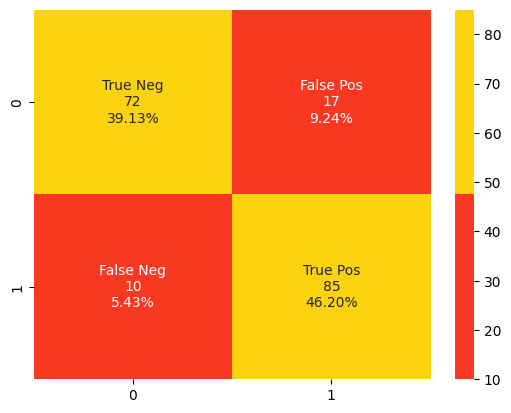

In [18]:
model_evaluation(classifier_lgbm)

### 6. CatBoost

Accuracy :  86.41%


Cross Validation Score :  92.36%
ROC_AUC Score :  86.35%


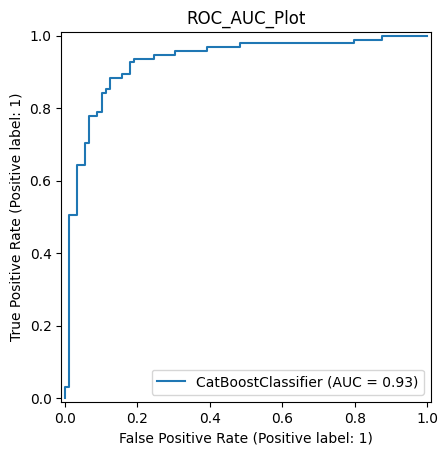

In [19]:
from catboost import CatBoostClassifier

classifier_cat = CatBoostClassifier(iterations = 300, depth = 3, learning_rate = 0.05,
                                    random_state = 42, verbose = False)
model(classifier_cat)

              precision    recall  f1-score   support

           0       0.87      0.84      0.86        89
           1       0.86      0.88      0.87        95

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



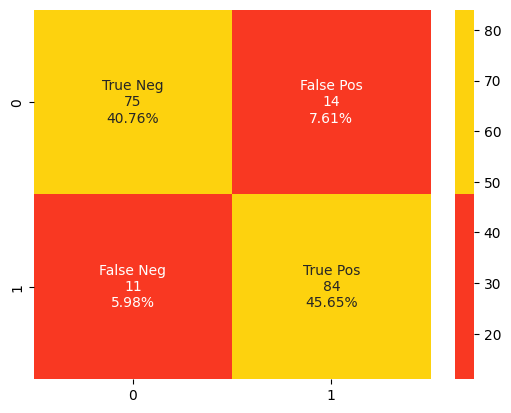

In [20]:
model_evaluation(classifier_cat)

## Model Comparison

Rank every classifier by mean repeated-stratified 10-fold ROC-AUC on the
training split (the same CV used in the per-model reports above) and pick the
best. The winner is refit on the full training split for explainability and
export.

In [21]:
candidates = {
    'logistic_regression': classifier_lr,
    'svc': classifier_svc,
    'decision_tree': classifier_dt,
    'random_forest': classifier_rf,
    'lightgbm': classifier_lgbm,
    'catboost': classifier_cat,
}

cv = RepeatedStratifiedKFold(n_splits = 10, n_repeats = 3, random_state = 1)
cv_scores = {name: float(cross_val_score(clf, x_train, y_train, cv = cv, scoring = 'roc_auc').mean())
             for name, clf in candidates.items()}

ranking = sorted(cv_scores.items(), key = lambda kv: kv[1], reverse = True)
print('CV ROC-AUC ranking:')
for name, score in ranking:
    print(f'  {name:<20} {score:.4f}')

best_name, best_score = ranking[0]
best_clf = candidates[best_name]
best_clf.fit(x_train, y_train)
print(f'\nBest model: {best_name} (CV ROC-AUC = {best_score:.4f})')

CV ROC-AUC ranking:
  random_forest        0.9247
  lightgbm             0.9246
  catboost             0.9236
  logistic_regression  0.9119
  svc                  0.9035
  decision_tree        0.8809

Best model: random_forest (CV ROC-AUC = 0.9247)


## Hyperparameter Tuning (top 3 models)

Grid-search the three strongest models from the comparison above with 5-fold
stratified CV on ROC-AUC. `GridSearchCV` refits the best estimator on the full
training split, so the winner is ready for explainability and export. This
overrides `best_clf` / `best_name` with the tuned selection.

In [22]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

top3 = [name for name, _ in ranking[:3]]
print('Tuning top 3:', top3, '\n')

base_estimators = {
    'logistic_regression': LogisticRegression(random_state = 0, max_iter = 2000),
    'svc': SVC(kernel = 'linear', probability = True, random_state = 0),
    'decision_tree': DecisionTreeClassifier(random_state = 1000),
    'random_forest': RandomForestClassifier(random_state = 0, n_jobs = -1),
    'lightgbm': LGBMClassifier(random_state = 42, n_jobs = 1, verbose = -1),
    'catboost': CatBoostClassifier(random_state = 42, verbose = False, thread_count = 1),
}
param_grids = {
    'logistic_regression': {'C': [0.01, 0.1, 1, 10], 'class_weight': [None, 'balanced']},
    'svc': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    'decision_tree': {'max_depth': [3, 4, 5, 6], 'min_samples_leaf': [1, 5, 10]},
    'random_forest': {'n_estimators': [200, 400], 'max_depth': [4, 8, None], 'min_samples_leaf': [1, 5]},
    'lightgbm': {'n_estimators': [200, 400], 'max_depth': [3, 5, -1], 'learning_rate': [0.03, 0.05, 0.1]},
    'catboost': {'iterations': [200, 400], 'depth': [3, 4, 6], 'learning_rate': [0.03, 0.05, 0.1]},
}

gs_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
tuned, tuned_scores, best_params = {}, {}, {}
for name in top3:
    search = GridSearchCV(base_estimators[name], param_grids[name],
                          scoring = 'roc_auc', cv = gs_cv, n_jobs = -1, refit = True)
    search.fit(x_train, y_train)
    tuned[name] = search.best_estimator_
    tuned_scores[name] = float(search.best_score_)
    best_params[name] = search.best_params_
    print(f'{name:<20} CV ROC-AUC {search.best_score_:.4f}   {search.best_params_}')

tuned_ranking = sorted(tuned_scores.items(), key = lambda kv: kv[1], reverse = True)
best_name, best_score = tuned_ranking[0]
best_clf = tuned[best_name]
best_params_selected = best_params[best_name]
print(f'\nBest tuned model: {best_name} (CV ROC-AUC = {best_score:.4f})')
print('Best params:', best_params_selected)

Tuning top 3: ['random_forest', 'lightgbm', 'catboost'] 



random_forest        CV ROC-AUC 0.9251   {'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 200}


/Users/joel/work/projects/solutions-healthcare-demos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/joel/work/projects/solutions-healthcare-demos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/joel/work/projects/solutions-healthcare-demos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/joel/work/projects/solutions-healthcare-demos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/joel/work/projects/solutions-healthcare-demos

/Users/joel/work/projects/solutions-healthcare-demos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/joel/work/projects/solutions-healthcare-demos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/joel/work/projects/solutions-healthcare-demos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/joel/work/projects/solutions-healthcare-demos/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/joel/work/projects/solutions-healthcare-demos

lightgbm             CV ROC-AUC 0.9275   {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200}


catboost             CV ROC-AUC 0.9306   {'depth': 4, 'iterations': 200, 'learning_rate': 0.03}

Best tuned model: catboost (CV ROC-AUC = 0.9306)
Best params: {'depth': 4, 'iterations': 200, 'learning_rate': 0.03}


## Explainability (SHAP)

Explain the selected model with SHAP. Tree models (decision tree, random forest,
LightGBM, CatBoost) use the fast `TreeExplainer`; other models fall back to the
model-agnostic explainer. The beeswarm shows how each feature pushes individual
predictions and the bar plot ranks global feature importance.

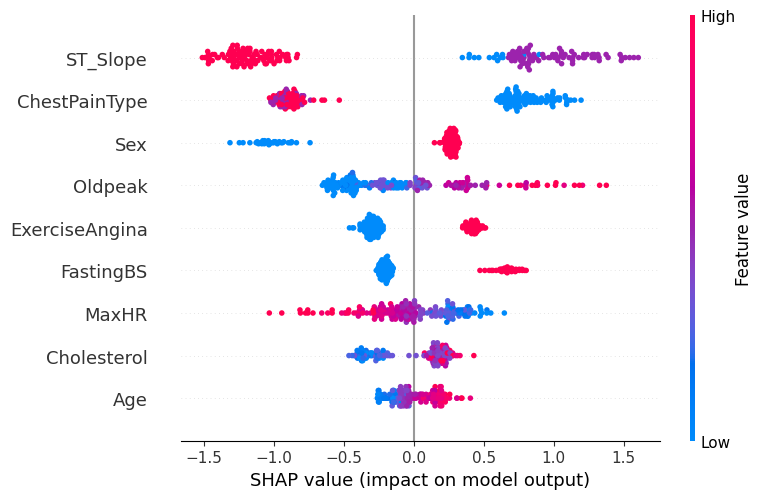

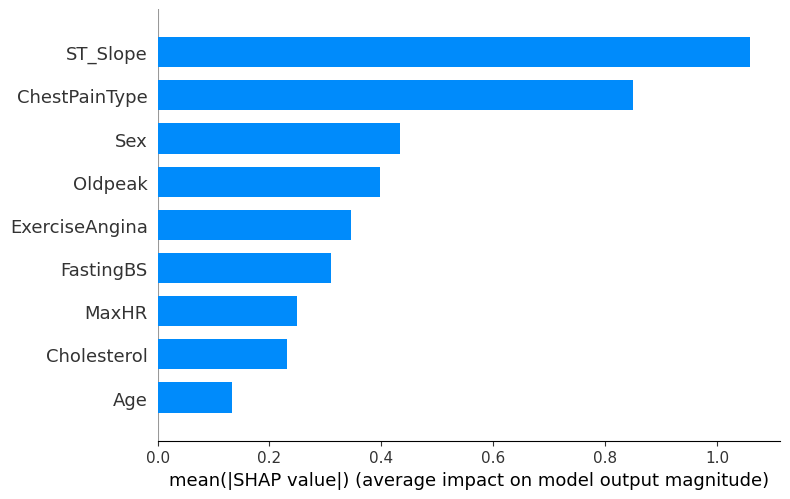

In [23]:
import shap

tree_models = {'decision_tree', 'random_forest', 'lightgbm', 'catboost'}
if best_name in tree_models:
    explainer = shap.TreeExplainer(best_clf)
    shap_values = explainer.shap_values(x_test)
    # Binary output can arrive as a per-class list or a 3D array; take positive class.
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    elif getattr(shap_values, 'ndim', 2) == 3:
        shap_values = shap_values[:, :, 1]
else:
    explainer = shap.Explainer(best_clf.predict_proba, x_train, feature_names = feature_names)
    shap_values = explainer(x_test)[..., 1].values

shap.summary_plot(shap_values, x_test, feature_names = feature_names, show = True)
shap.summary_plot(shap_values, x_test, feature_names = feature_names, plot_type = 'bar', show = True)

## Export the Best Model (write alongside)

Persist the selected model next to the service's committed artifacts without
overwriting them: `heart_watch_model_nb.joblib`, `metrics_nb.json`, and a
best-effort ONNX export. These are trained on the wider clinical feature set and
on already-preprocessed inputs, so they are a separate exploration artifact from
the service's watch-only `heart_watch_model.onnx`.

In [24]:
import json
import joblib
from pathlib import Path
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score)

models_dir = Path('../models')
models_dir.mkdir(exist_ok = True)

pred = best_clf.predict(x_test)
try:
    proba = best_clf.predict_proba(x_test)[:, 1]
except AttributeError:
    proba = best_clf.decision_function(x_test)
test_metrics = {
    'roc_auc': float(roc_auc_score(y_test, proba)),
    'accuracy': float(accuracy_score(y_test, pred)),
    'precision': float(precision_score(y_test, pred)),
    'recall': float(recall_score(y_test, pred)),
    'f1': float(f1_score(y_test, pred)),
}
print('Held-out test metrics:', {k: round(v, 4) for k, v in test_metrics.items()})

joblib.dump(best_clf, models_dir / 'heart_watch_model_nb.joblib')
(models_dir / 'metrics_nb.json').write_text(json.dumps({
    'selected_model': best_name,
    'selected_params': best_params_selected,
    'features': feature_names,
    'preprocessing': ('LabelEncoder on categoricals; StandardScaler on '
                      'Age/Cholesterol/MaxHR; MinMaxScaler on Oldpeak; '
                      'Cholesterol/RestingBP zeros median-imputed'),
    'cv_roc_auc_untuned': cv_scores,
    'cv_roc_auc_tuned': tuned_scores,
    'best_params': best_params,
    'test_metrics': test_metrics,
    'n_train': int(len(x_train)),
    'n_test': int(len(x_test)),
    'note': ('Notebook exploration on the wider clinical feature set, trained on '
             'preprocessed inputs. Separate from the service watch-only ONNX.'),
}, indent = 2))
print('Saved heart_watch_model_nb.joblib + metrics_nb.json')

# Best-effort ONNX export. Inputs are the preprocessed feature vector.
onnx_path = models_dir / 'heart_watch_model_nb.onnx'
try:
    if best_name == 'catboost':
        best_clf.save_model(str(onnx_path), format = 'onnx')
    else:
        from skl2onnx import convert_sklearn, update_registered_converter
        from skl2onnx.common.data_types import FloatTensorType
        from skl2onnx.common.shape_calculator import calculate_linear_classifier_output_shapes
        if best_name == 'lightgbm':
            from lightgbm import LGBMClassifier
            from onnxmltools.convert.lightgbm.operator_converters.LightGbm import convert_lightgbm
            update_registered_converter(
                LGBMClassifier, 'LightGbmLGBMClassifier',
                calculate_linear_classifier_output_shapes, convert_lightgbm,
                options = {'nocl': [True, False], 'zipmap': [True, False, 'columns']})
        initial_types = [('input', FloatTensorType([None, len(feature_names)]))]
        onx = convert_sklearn(best_clf, initial_types = initial_types,
                              options = {'zipmap': False},
                              target_opset = {'': 18, 'ai.onnx.ml': 3})
        onnx_path.write_bytes(onx.SerializeToString())
    print(f'Saved ONNX -> {onnx_path}')
except Exception as e:
    print(f'ONNX export skipped: {type(e).__name__}: {e}')

Held-out test metrics: {'roc_auc': 0.928, 'accuracy': 0.8696, 'precision': 0.8515, 'recall': 0.9053, 'f1': 0.8776}
Saved heart_watch_model_nb.joblib + metrics_nb.json
Saved ONNX -> ../models/heart_watch_model_nb.onnx
